In [1]:
import sys
from pathlib import Path

# プロジェクトのルートディレクトリをパスに追加
project_root = Path.cwd().parent.parent  # notebooks/assistments_2009_2010/ から2階層上がる
sys.path.insert(0, str(project_root))

print(f"Added to path: {project_root}")

import torch
import numpy as np
import pandas as pd
from typing import Dict, Any
import os

# 作業ディレクトリをプロジェクトルートに変更
os.chdir(project_root)
print(f"Changed working directory to: {os.getcwd()}")

from src.utils.config_synthetic import load_yaml, generate_grid
from src.utils.seed import set_seed, derive_seed
from src.utils.device import get_device
from src.methods.registry import build_method
from src.datasets.generate_assistments_2009_2010_data import generate_data
from src.datasets.factory import build_dataset, build_test_dataset
from src.evaluation.evaluator import evaluate_testdata, evaluate_distribution


base_cfg = load_yaml("configs/Assistments_2009_2010/base.yaml")
train_cfg = load_yaml("configs/Assistments_2009_2010/train.yaml")

device = get_device()

for dataset_cfg in base_cfg["dataset"]:
    records = []  # データセットごとに初期化
    pre_current_dataset, pre_future_dataset = generate_data(data_dir=dataset_cfg["id"], n_skills=dataset_cfg["n_skills"])
    split_ratio = base_cfg["split_ratio"]
    print(pre_current_dataset.shape, pre_future_dataset.shape)


    print(f"=== Dataset: {dataset_cfg['name']} ===")
    print(f"Number of students: {len(pre_current_dataset)}")
    print(f"Number of skills: {dataset_cfg['n_skills']}")
    print(pre_current_dataset)
    print(pre_future_dataset)
    continue

    for seed in base_cfg["seeds"]:
        # seedを使ってシャッフル
        n_samples = len(pre_current_dataset)
        rng = np.random.RandomState(seed)
        indices = rng.permutation(n_samples)
        
        # シャッフルされたデータ
        shuffled_current = pre_current_dataset[indices]
        shuffled_future = pre_future_dataset[indices]
        
        # train/test分割
        split_idx = int(n_samples * split_ratio)
        current_dataset = shuffled_current[:split_idx]
        future_dataset = shuffled_future[:split_idx]
        test_future = shuffled_future[split_idx:]
        
        test_data = {
            "X_test": torch.from_numpy(test_future[:, 0, :]).to(device),
            "y_test": torch.from_numpy(test_future[:, 1, :]).to(device),
        }
        for method_cfg in base_cfg["methods"]:
            method_seed = derive_seed(seed, method_cfg["id"])  # methodごとに分ける
            set_seed(method_seed)

            # exp_cfgを作成（proposedメソッドの場合のみ必要）
            if method_cfg["id"] in ["proposed", "full_information"]:
                exp_cfg = {
                    "n_students": len(current_dataset),
                    "n_skills": dataset_cfg["n_skills"],
                    "dataset_name": dataset_cfg["name"],
                }
            else:
                exp_cfg = None

            # モデル定義
            method = build_method(
                method_cfg=method_cfg,
                device=device,
                seed=method_seed,
                exp_cfg=exp_cfg,
                training_cfg=train_cfg if exp_cfg is not None else None,
                save=False,
            )

            # モデル学習
            train_data = build_dataset(
                method_cfg=method_cfg,
                current_dataset=current_dataset,
                future_dataset=future_dataset,
                device=device,
            )
            method.fit(train_data)

            # テストデータ予測
            out = method.predict(test_data)

            # 評価
            test_metrics = base_cfg["evaluation"]["test_metrics"]

            scores_testdata = evaluate_testdata(
                pred=out,
                input=test_data["X_test"].cpu().numpy(),
                target=test_data["y_test"].cpu().numpy(),
                metrics=test_metrics,
            )
            record = {
                "seed": seed,
                "method": method_cfg["id"],
            }
            for k, v in scores_testdata.items():
                record[k] = v
            records.append(record)

    # === 保存 ===
    results_dir = Path(base_cfg["results_folder"])
    results_dir.mkdir(parents=True, exist_ok=True)

    df = pd.DataFrame(records)
    exp_name = dataset_cfg["name"]
    csv_path = results_dir / f"{exp_name}_{train_cfg['recipe']['regularization']['type']}_{train_cfg['recipe']['regularization']['lambda']}.csv"

    df.to_csv(csv_path, index=False)


Added to path: /Users/nagairyousuke/Documents/kashima_lab/master_paper
Changed working directory to: /Users/nagairyousuke/Documents/kashima_lab/master_paper


/Users/nagairyousuke/Documents/kashima_lab/master_paper/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
データセット生成完了:
  学生数: 208
  スキル数: 5
  前半平均習得率: 61.44%
  後半平均習得率（元）: 62.50%
  後半平均習得率（新）: 75.10%

スキル状態の変化:
  習得: 142件 (13.65%)
  ⚠️  喪失: 131件 (12.60%) → 論理和で修正済み
  維持: 508件 (48.85%)
  未習得: 259件 (24.90%)

学生ごとの習得スキル数:
  前半平均: 3.07 / 5
  後半平均（元）: 3.12 / 5
  後半平均（新）: 3.75 / 5
  平均純増: 0.68
  平均純増（元）: 0.05
(208, 2, 5) (208, 2, 5)
=== Dataset: s2_s37_s48_s70_s77 ===
Number of students: 208
Number of skills: 5
[[[0. 0. 0. 0. 0.]
  [1. 0. 0. 1. 1.]]

 [[0. 0. 0. 0. 0.]
  [1. 0. 0. 1. 1.]]

 [[0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]

 ...

 [[0. 0. 0. 0. 0.]
  [1. 1. 1. 1. 1.]]

 [[0. 0. 0. 0. 0.]
  [1. 1. 1. 1. 1.]]

 [[0. 0. 0. 0. 0.]
  [1. 1. 1. 1. 1.]]]
[[[1. 0. 0. 1. 1.]
  [1. 1. 1. 1. 1.]]

 [[1. 0. 0. 1. 1.]
  [1. 0. 0. 1. 1.]]

 [[0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0.]]

 ...

 [[1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]]

 [[1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]]

 [[1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1.]]]


データセット生成完了:
  学生数: 208
  スキル数: 5
  前半平均習得率: 61.44%
  後半平均習得率（元）: 62.50%
  後半平均習得率（新）: 75.10%

スキル状態の変化:
  習得: 142件 (13.65%)
  ⚠️  喪失: 131件 (12.60%) → 論理和で修正済み
  維持: 508件 (48.85%)
  未習得: 259件 (24.90%)

学生ごとの習得スキル数:
  前半平均: 3.07 / 5
  後半平均（元）: 3.12 / 5
  後半平均（新）: 3.75 / 5
  平均純増: 0.68
  平均純増（元）: 0.05

=== Dataset: s2_s37_s48_s70_s77 ===
Number of students: 208
Number of skills: 5

Skill Statistics:


,Skill,Current,Future,New Learners
0,Skill 1,130.0,160.0,30.0
1,Skill 2,122.0,151.0,29.0
2,Skill 3,128.0,152.0,24.0
3,Skill 4,134.0,159.0,25.0
4,Skill 5,125.0,159.0,34.0


/var/folders/zg/773ptkr55z99zw26dvy19_v00000gn/T/ipykernel_98560/662662920.py:108: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax5.boxplot(box_data, labels=['Current', 'Future', 'New'],


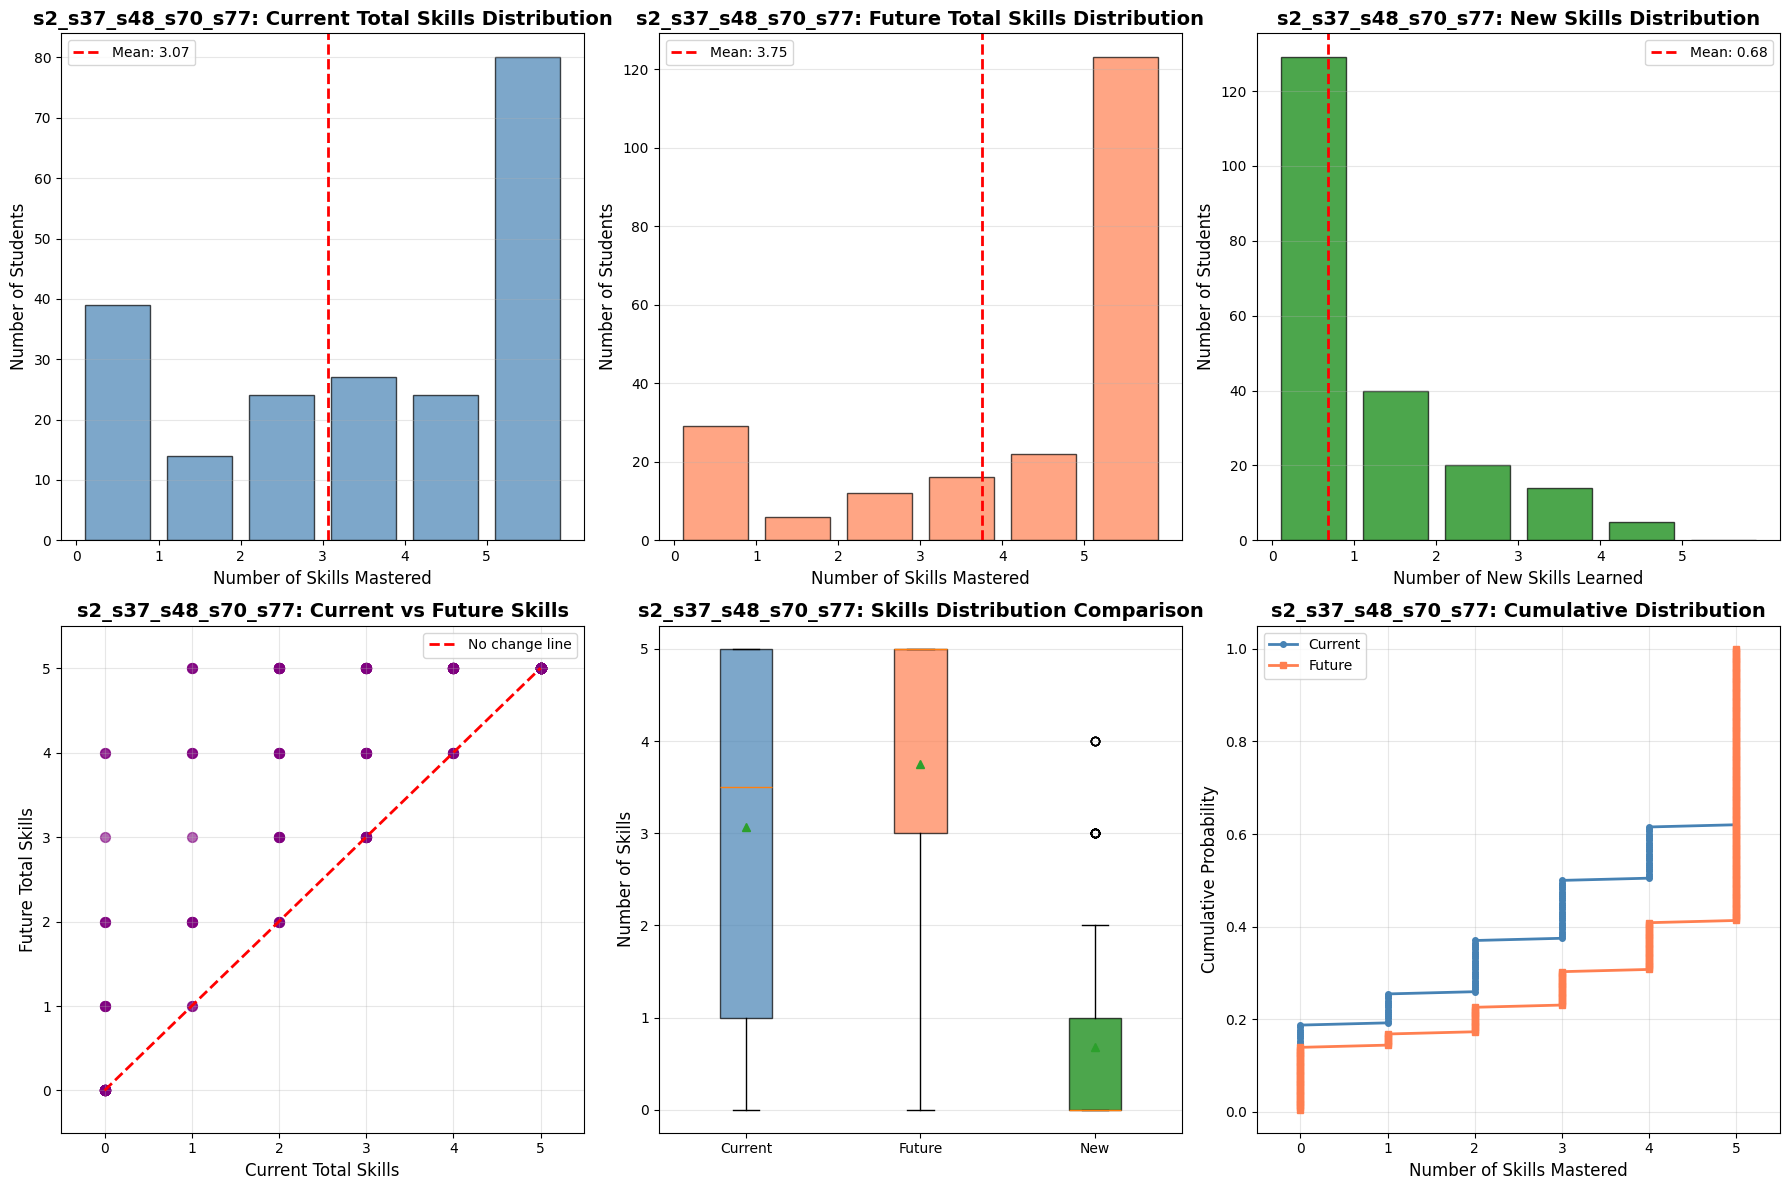


=== Total Skills Statistics ===
Current Total Skills:
  Mean: 3.07
  Std: 1.93
  Min: 0
  Max: 5
  Median: 4

Future Total Skills:
  Mean: 3.75
  Std: 1.82
  Min: 0
  Max: 5
  Median: 5

New Skills Learned:
  Mean: 0.68
  Std: 1.05
  Min: 0
  Max: 4
  Median: 0

=== Distribution Details ===
0 skills: Current=39, Future=29, New=129
1 skills: Current=14, Future=6, New=40
2 skills: Current=24, Future=12, New=20
3 skills: Current=27, Future=16, New=14
4 skills: Current=24, Future=22, New=5
5 skills: Current=80, Future=123, New=0


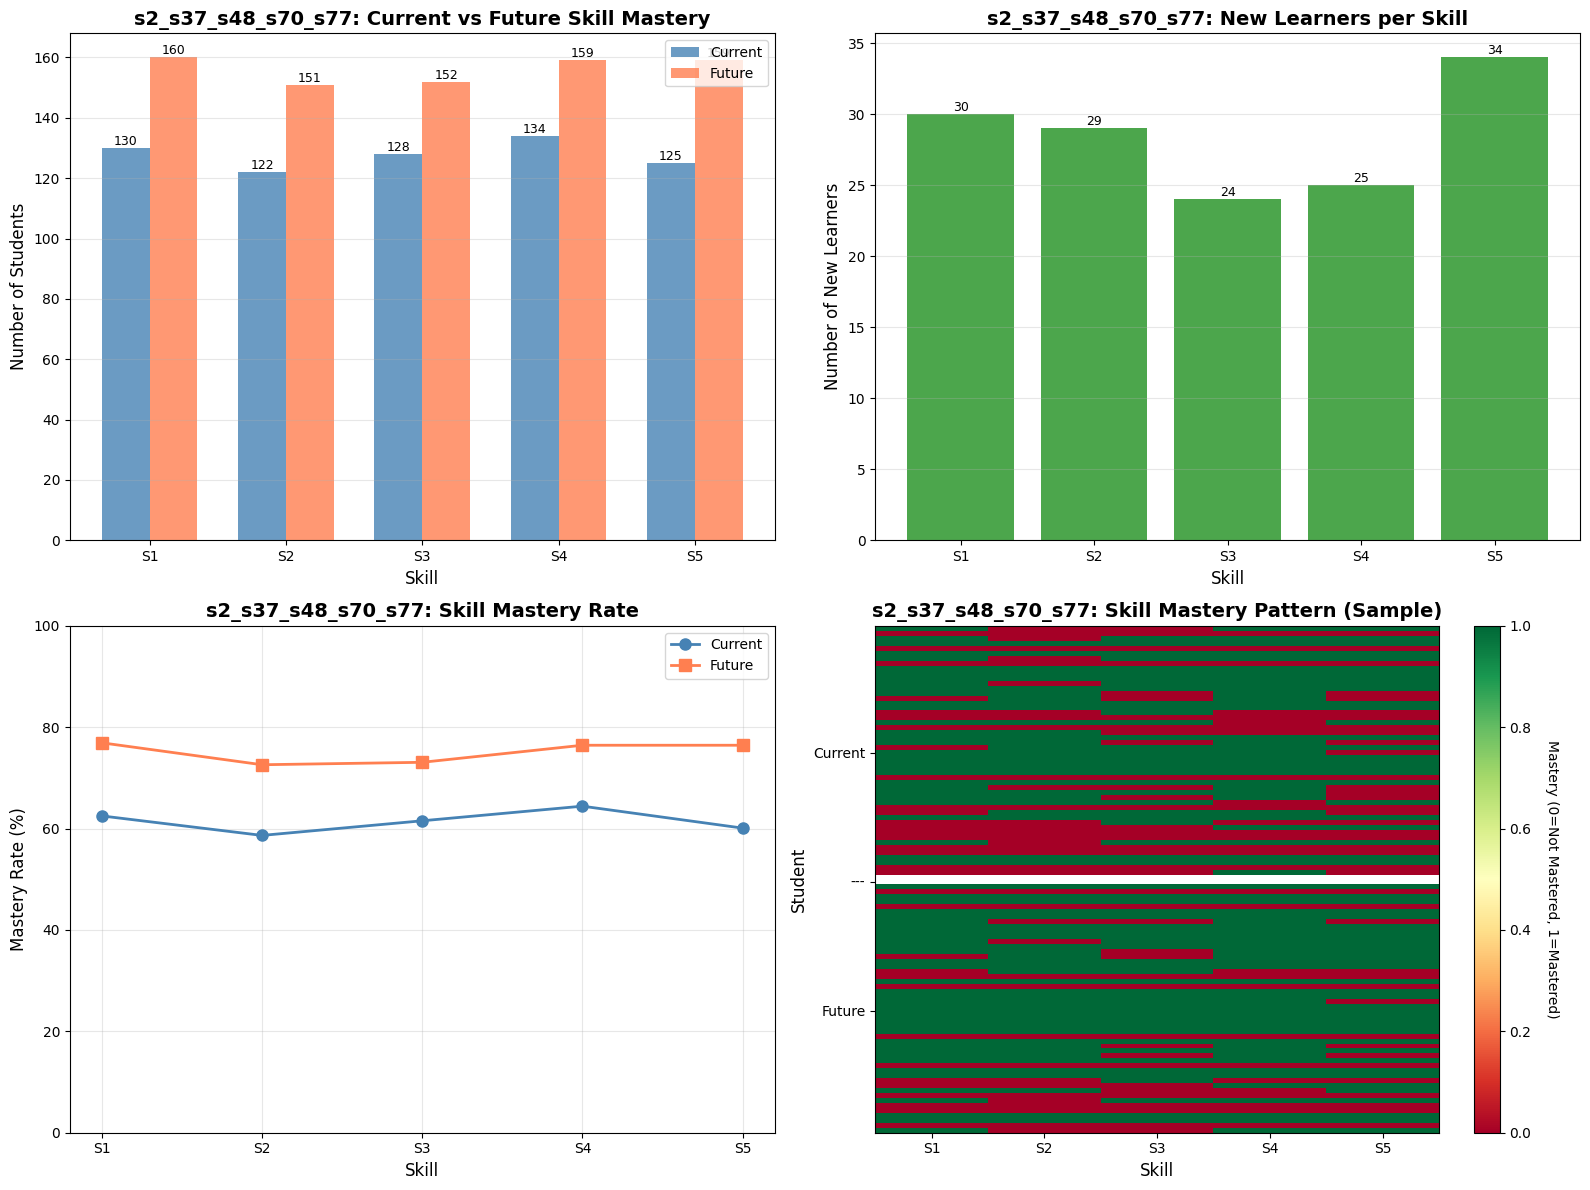


=== Skill Co-occurrence (Current) ===


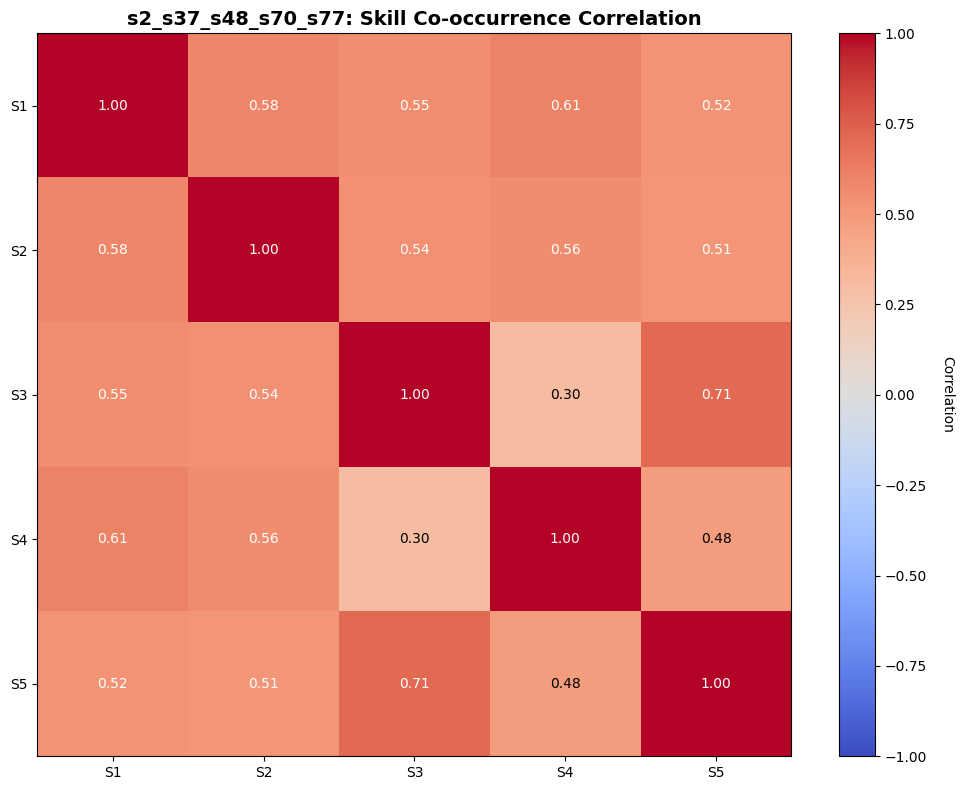

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 日本語フォント設定
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (14, 10)

for dataset_cfg in base_cfg["dataset"]:
    pre_current_dataset, pre_future_dataset = generate_data(
        data_dir=dataset_cfg["id"], 
        n_skills=dataset_cfg["n_skills"]
    )
    
    # 現在の習得状態と将来の習得状態
    current_skills = pre_future_dataset[:, 0, :]  # (n_students, n_skills)
    future_skills = pre_future_dataset[:, 1, :]   # (n_students, n_skills)
    
    n_skills = dataset_cfg["n_skills"]
    n_students = len(current_skills)
    
    print(f"\n=== Dataset: {dataset_cfg['name']} ===")
    print(f"Number of students: {n_students}")
    print(f"Number of skills: {n_skills}")
    
    # 各スキルの習得人数を集計
    current_counts = current_skills.sum(axis=0)  # (n_skills,)
    future_counts = future_skills.sum(axis=0)    # (n_skills,)
    new_learners = future_counts - current_counts  # 新規習得者数
    
    # 学生ごとの総習得スキル数
    current_total_per_student = current_skills.sum(axis=1)  # (n_students,)
    future_total_per_student = future_skills.sum(axis=1)    # (n_students,)
    new_skills_per_student = future_total_per_student - current_total_per_student
    
    # データフレーム作成
    skill_stats = pd.DataFrame({
        'Skill': [f'Skill {i+1}' for i in range(n_skills)],
        'Current': current_counts,
        'Future': future_counts,
        'New Learners': new_learners
    })
    
    print("\nSkill Statistics:")
    display(skill_stats)
    
    # === グラフ1: 総習得スキル数の分布 ===
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. 現在の総習得スキル数の分布（ヒストグラム）
    ax1 = axes[0, 0]
    ax1.hist(current_total_per_student, bins=range(0, n_skills+2), 
             alpha=0.7, color='steelblue', edgecolor='black', rwidth=0.8)
    ax1.axvline(current_total_per_student.mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {current_total_per_student.mean():.2f}')
    ax1.set_xlabel('Number of Skills Mastered', fontsize=12)
    ax1.set_ylabel('Number of Students', fontsize=12)
    ax1.set_title(f'{dataset_cfg["name"]}: Current Total Skills Distribution', 
                  fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_xticks(range(0, n_skills+1))
    
    # 2. 将来の総習得スキル数の分布（ヒストグラム）
    ax2 = axes[0, 1]
    ax2.hist(future_total_per_student, bins=range(0, n_skills+2), 
             alpha=0.7, color='coral', edgecolor='black', rwidth=0.8)
    ax2.axvline(future_total_per_student.mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {future_total_per_student.mean():.2f}')
    ax2.set_xlabel('Number of Skills Mastered', fontsize=12)
    ax2.set_ylabel('Number of Students', fontsize=12)
    ax2.set_title(f'{dataset_cfg["name"]}: Future Total Skills Distribution', 
                  fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    ax2.set_xticks(range(0, n_skills+1))
    
    # 3. 新規習得スキル数の分布（ヒストグラム）
    ax3 = axes[0, 2]
    ax3.hist(new_skills_per_student, bins=range(0, n_skills+2), 
             alpha=0.7, color='green', edgecolor='black', rwidth=0.8)
    ax3.axvline(new_skills_per_student.mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {new_skills_per_student.mean():.2f}')
    ax3.set_xlabel('Number of New Skills Learned', fontsize=12)
    ax3.set_ylabel('Number of Students', fontsize=12)
    ax3.set_title(f'{dataset_cfg["name"]}: New Skills Distribution', 
                  fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    ax3.set_xticks(range(0, n_skills+1))
    
    # 4. 現在 vs 将来の散布図
    ax4 = axes[1, 0]
    ax4.scatter(current_total_per_student, future_total_per_student, 
                alpha=0.6, s=50, color='purple')
    ax4.plot([0, n_skills], [0, n_skills], 'r--', linewidth=2, label='No change line')
    ax4.set_xlabel('Current Total Skills', fontsize=12)
    ax4.set_ylabel('Future Total Skills', fontsize=12)
    ax4.set_title(f'{dataset_cfg["name"]}: Current vs Future Skills', 
                  fontsize=14, fontweight='bold')
    ax4.legend()
    ax4.grid(alpha=0.3)
    ax4.set_xlim(-0.5, n_skills+0.5)
    ax4.set_ylim(-0.5, n_skills+0.5)
    
    # 5. 箱ひげ図（現在、将来、新規）
    ax5 = axes[1, 1]
    box_data = [current_total_per_student, future_total_per_student, new_skills_per_student]
    bp = ax5.boxplot(box_data, labels=['Current', 'Future', 'New'], 
                     patch_artist=True, showmeans=True)
    
    colors = ['steelblue', 'coral', 'green']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax5.set_ylabel('Number of Skills', fontsize=12)
    ax5.set_title(f'{dataset_cfg["name"]}: Skills Distribution Comparison', 
                  fontsize=14, fontweight='bold')
    ax5.grid(axis='y', alpha=0.3)
    
    # 6. 累積分布関数（CDF）
    ax6 = axes[1, 2]
    
    # 現在のCDF
    current_sorted = np.sort(current_total_per_student)
    current_cdf = np.arange(1, len(current_sorted)+1) / len(current_sorted)
    ax6.plot(current_sorted, current_cdf, marker='o', markersize=4, 
             linewidth=2, label='Current', color='steelblue')
    
    # 将来のCDF
    future_sorted = np.sort(future_total_per_student)
    future_cdf = np.arange(1, len(future_sorted)+1) / len(future_sorted)
    ax6.plot(future_sorted, future_cdf, marker='s', markersize=4, 
             linewidth=2, label='Future', color='coral')
    
    ax6.set_xlabel('Number of Skills Mastered', fontsize=12)
    ax6.set_ylabel('Cumulative Probability', fontsize=12)
    ax6.set_title(f'{dataset_cfg["name"]}: Cumulative Distribution', 
                  fontsize=14, fontweight='bold')
    ax6.legend()
    ax6.grid(alpha=0.3)
    ax6.set_xlim(-0.5, n_skills+0.5)
    
    plt.tight_layout()
    plt.show()
    
    # === 統計サマリー（総習得スキル数） ===
    print("\n=== Total Skills Statistics ===")
    print(f"Current Total Skills:")
    print(f"  Mean: {current_total_per_student.mean():.2f}")
    print(f"  Std: {current_total_per_student.std():.2f}")
    print(f"  Min: {current_total_per_student.min():.0f}")
    print(f"  Max: {current_total_per_student.max():.0f}")
    print(f"  Median: {np.median(current_total_per_student):.0f}")
    
    print(f"\nFuture Total Skills:")
    print(f"  Mean: {future_total_per_student.mean():.2f}")
    print(f"  Std: {future_total_per_student.std():.2f}")
    print(f"  Min: {future_total_per_student.min():.0f}")
    print(f"  Max: {future_total_per_student.max():.0f}")
    print(f"  Median: {np.median(future_total_per_student):.0f}")
    
    print(f"\nNew Skills Learned:")
    print(f"  Mean: {new_skills_per_student.mean():.2f}")
    print(f"  Std: {new_skills_per_student.std():.2f}")
    print(f"  Min: {new_skills_per_student.min():.0f}")
    print(f"  Max: {new_skills_per_student.max():.0f}")
    print(f"  Median: {np.median(new_skills_per_student):.0f}")
    
    # 分布の詳細
    print(f"\n=== Distribution Details ===")
    for i in range(0, n_skills+1):
        current_count = (current_total_per_student == i).sum()
        future_count = (future_total_per_student == i).sum()
        new_count = (new_skills_per_student == i).sum()
        print(f"{i} skills: Current={current_count}, Future={future_count}, New={new_count}")
    
    # === 以前のグラフ（スキルごと） ===
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. 習得人数の比較（棒グラフ）
    ax1 = axes[0, 0]
    x = np.arange(n_skills)
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, current_counts, width, label='Current', alpha=0.8, color='steelblue')
    bars2 = ax1.bar(x + width/2, future_counts, width, label='Future', alpha=0.8, color='coral')
    
    ax1.set_xlabel('Skill', fontsize=12)
    ax1.set_ylabel('Number of Students', fontsize=12)
    ax1.set_title(f'{dataset_cfg["name"]}: Current vs Future Skill Mastery', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # 棒の上に数値を表示
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=9)
    
    # 2. 新規習得者数（棒グラフ）
    ax2 = axes[0, 1]
    bars3 = ax2.bar(x, new_learners, color='green', alpha=0.7)
    
    ax2.set_xlabel('Skill', fontsize=12)
    ax2.set_ylabel('Number of New Learners', fontsize=12)
    ax2.set_title(f'{dataset_cfg["name"]}: New Learners per Skill', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
    ax2.grid(axis='y', alpha=0.3)
    
    for bar in bars3:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9)
    
    # 3. 習得率の比較（折れ線グラフ）
    ax3 = axes[1, 0]
    current_rate = (current_counts / n_students) * 100
    future_rate = (future_counts / n_students) * 100
    
    ax3.plot(x, current_rate, marker='o', linewidth=2, markersize=8, label='Current', color='steelblue')
    ax3.plot(x, future_rate, marker='s', linewidth=2, markersize=8, label='Future', color='coral')
    
    ax3.set_xlabel('Skill', fontsize=12)
    ax3.set_ylabel('Mastery Rate (%)', fontsize=12)
    ax3.set_title(f'{dataset_cfg["name"]}: Skill Mastery Rate', fontsize=14, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
    ax3.legend()
    ax3.grid(alpha=0.3)
    ax3.set_ylim(0, 100)
    
    # 4. ヒートマップ（習得パターン）
    ax4 = axes[1, 1]
    
    # 習得状態の変化を可視化（サンプル50人まで）
    sample_size = min(50, n_students)
    indices = np.random.choice(n_students, sample_size, replace=False)
    
    # 現在と将来を縦に並べる
    combined = np.vstack([
        current_skills[indices],
        np.full((2, n_skills), np.nan),  # セパレータ
        future_skills[indices]
    ])
    
    im = ax4.imshow(combined, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax4.set_xlabel('Skill', fontsize=12)
    ax4.set_ylabel('Student', fontsize=12)
    ax4.set_title(f'{dataset_cfg["name"]}: Skill Mastery Pattern (Sample)', fontsize=14, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
    
    # Y軸のラベル
    yticks_pos = [sample_size//2, sample_size + 1, sample_size + 2 + sample_size//2]
    yticks_labels = ['Current', '---', 'Future']
    ax4.set_yticks(yticks_pos)
    ax4.set_yticklabels(yticks_labels)
    
    # カラーバー
    cbar = plt.colorbar(im, ax=ax4)
    cbar.set_label('Mastery (0=Not Mastered, 1=Mastered)', rotation=270, labelpad=20)
    
    plt.tight_layout()
    plt.show()
    
    # スキル間の相関（現在の習得状態）
    if n_skills > 1:
        print("\n=== Skill Co-occurrence (Current) ===")
        skill_corr = np.corrcoef(current_skills.T)
        
        fig, ax = plt.subplots(figsize=(10, 8))
        im = ax.imshow(skill_corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
        
        ax.set_xticks(x)
        ax.set_yticks(x)
        ax.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
        ax.set_yticklabels([f'S{i+1}' for i in range(n_skills)])
        ax.set_title(f'{dataset_cfg["name"]}: Skill Co-occurrence Correlation', fontsize=14, fontweight='bold')
        
        # 数値を表示
        for i in range(n_skills):
            for j in range(n_skills):
                text = ax.text(j, i, f'{skill_corr[i, j]:.2f}',
                             ha="center", va="center", color="black" if abs(skill_corr[i, j]) < 0.5 else "white",
                             fontsize=10)
        
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Correlation', rotation=270, labelpad=20)
        plt.tight_layout()
        plt.show()

データセット生成完了:
  学生数: 208
  スキル数: 5
  前半平均習得率: 61.44%
  後半平均習得率（元）: 62.50%
  後半平均習得率（新）: 75.10%

スキル状態の変化:
  習得: 142件 (13.65%)
  ⚠️  喪失: 131件 (12.60%) → 論理和で修正済み
  維持: 508件 (48.85%)
  未習得: 259件 (24.90%)

学生ごとの習得スキル数:
  前半平均: 3.07 / 5
  後半平均（元）: 3.12 / 5
  後半平均（新）: 3.75 / 5
  平均純増: 0.68
  平均純増（元）: 0.05

⚠️  future_datasetを元の後半データで生成しました（raw_future=True）

=== Dataset: s2_s37_s48_s70_s77 ===
Number of students: 208
Number of skills: 5

Skill Statistics:


,Skill,Current,Future,New Learners
0,Skill 1,130.0,152.0,22.0
1,Skill 2,122.0,119.0,-3.0
2,Skill 3,128.0,113.0,-15.0
3,Skill 4,134.0,130.0,-4.0
4,Skill 5,125.0,136.0,11.0


/var/folders/zg/773ptkr55z99zw26dvy19_v00000gn/T/ipykernel_98560/2536871294.py:109: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax5.boxplot(box_data, labels=['Current', 'Future', 'New'],


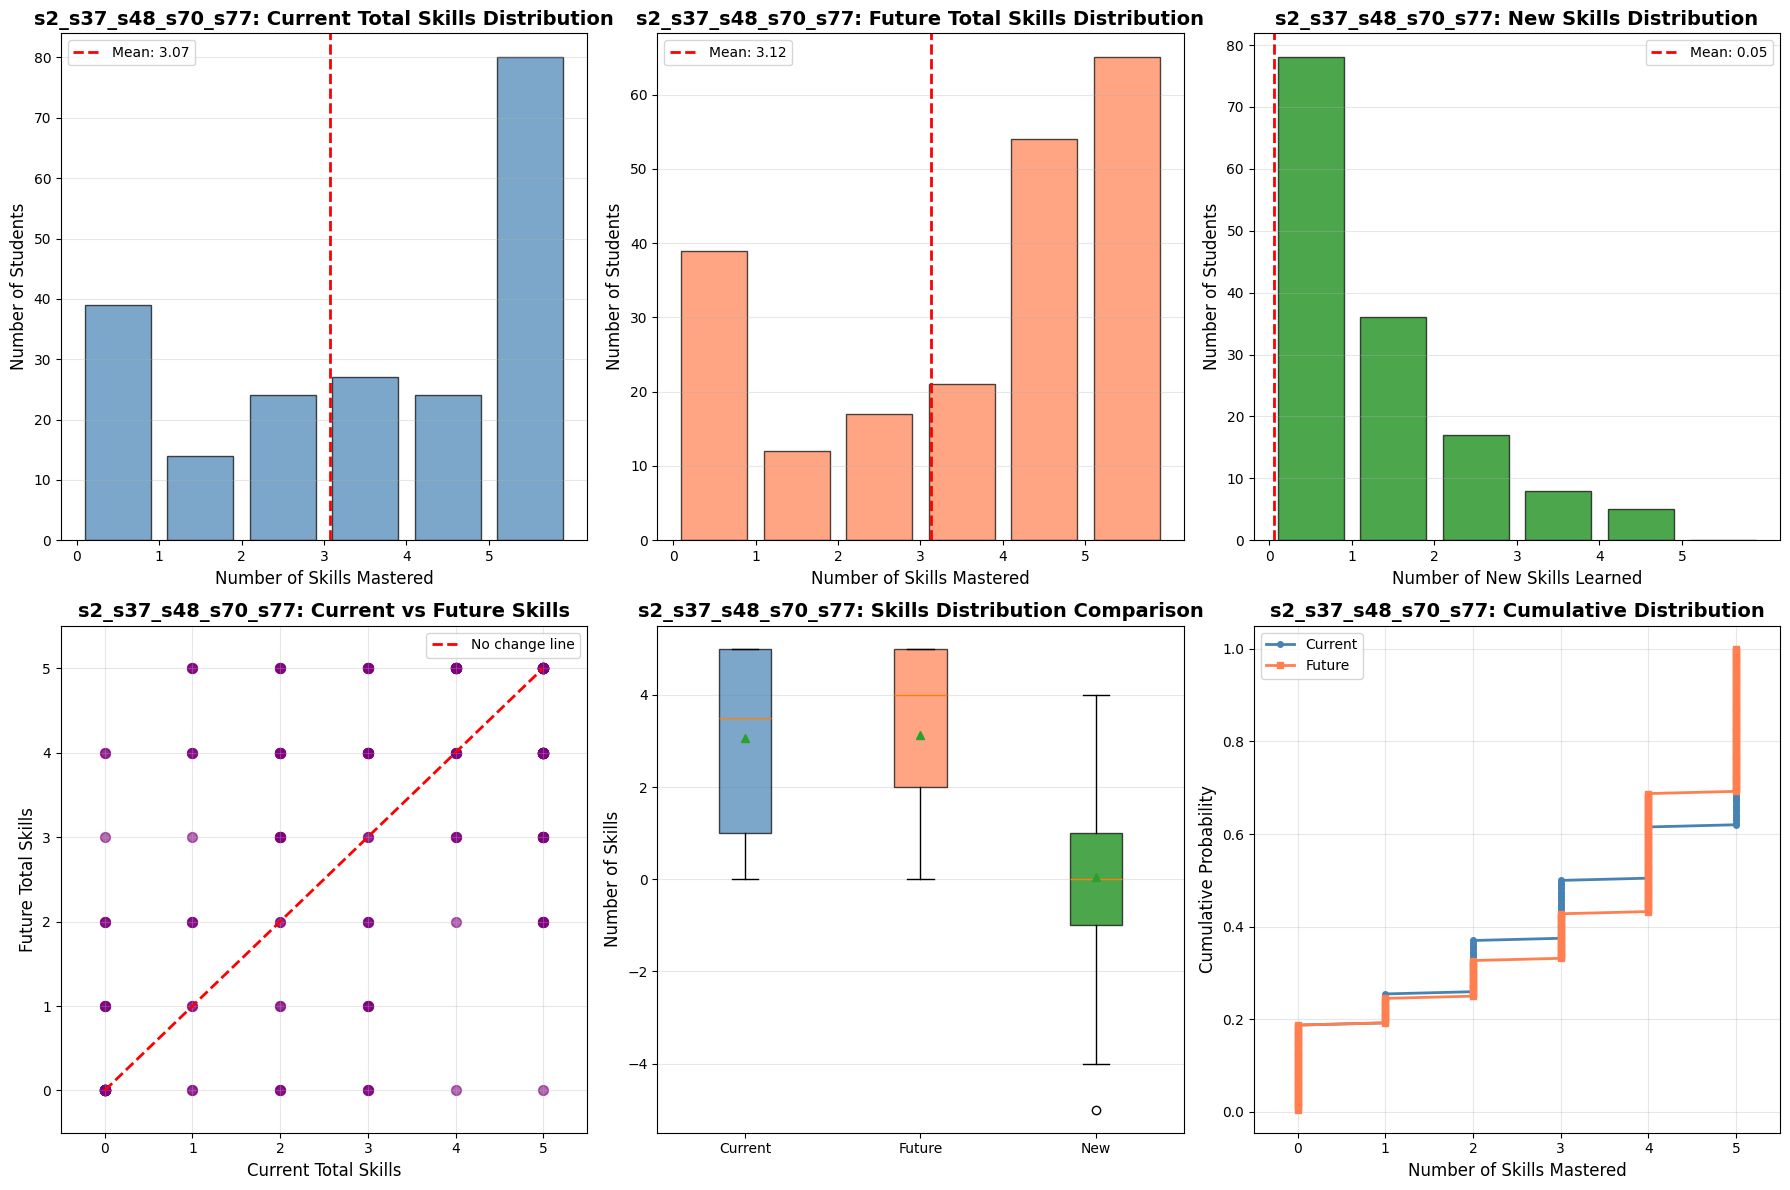


=== Total Skills Statistics ===
Current Total Skills:
  Mean: 3.07
  Std: 1.93
  Min: 0
  Max: 5
  Median: 4

Future Total Skills:
  Mean: 3.12
  Std: 1.87
  Min: 0
  Max: 5
  Median: 4

New Skills Learned:
  Mean: 0.05
  Std: 1.50
  Min: -5
  Max: 4
  Median: 0

=== Distribution Details ===
0 skills: Current=39, Future=39, New=78
1 skills: Current=14, Future=12, New=36
2 skills: Current=24, Future=17, New=17
3 skills: Current=27, Future=21, New=8
4 skills: Current=24, Future=54, New=5
5 skills: Current=80, Future=65, New=0


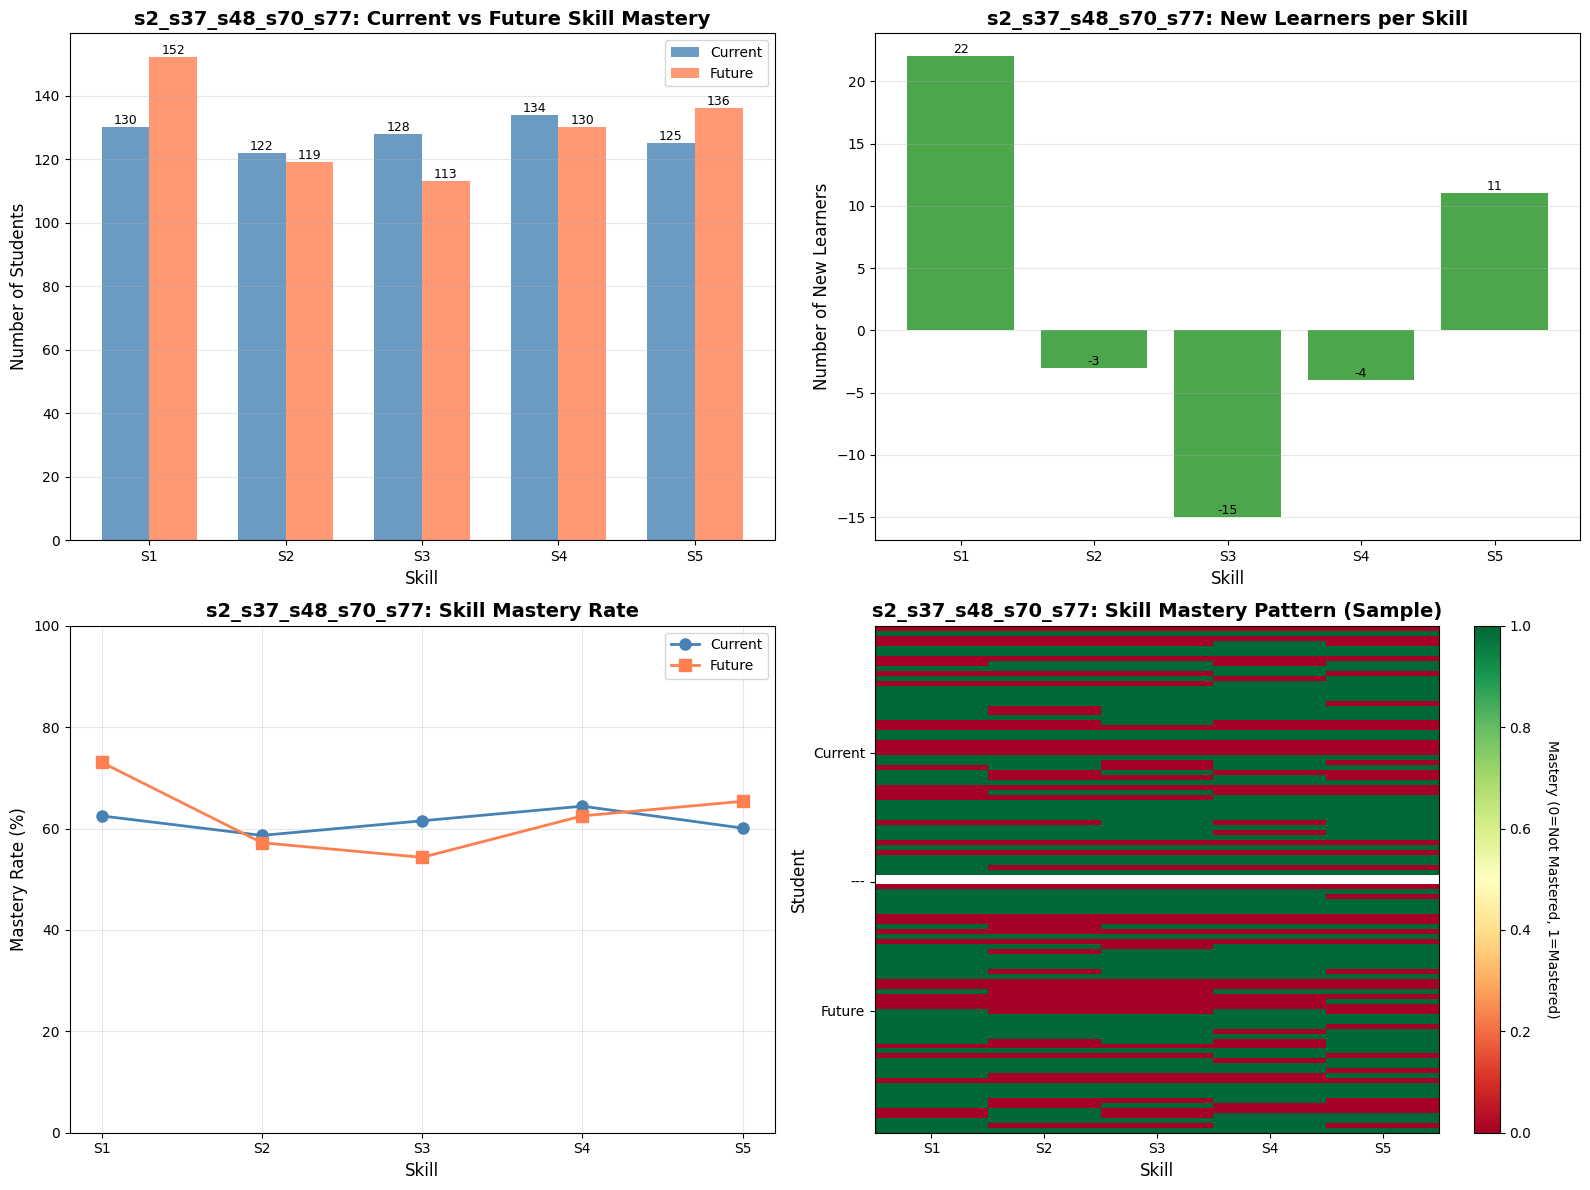


=== Skill Co-occurrence (Current) ===


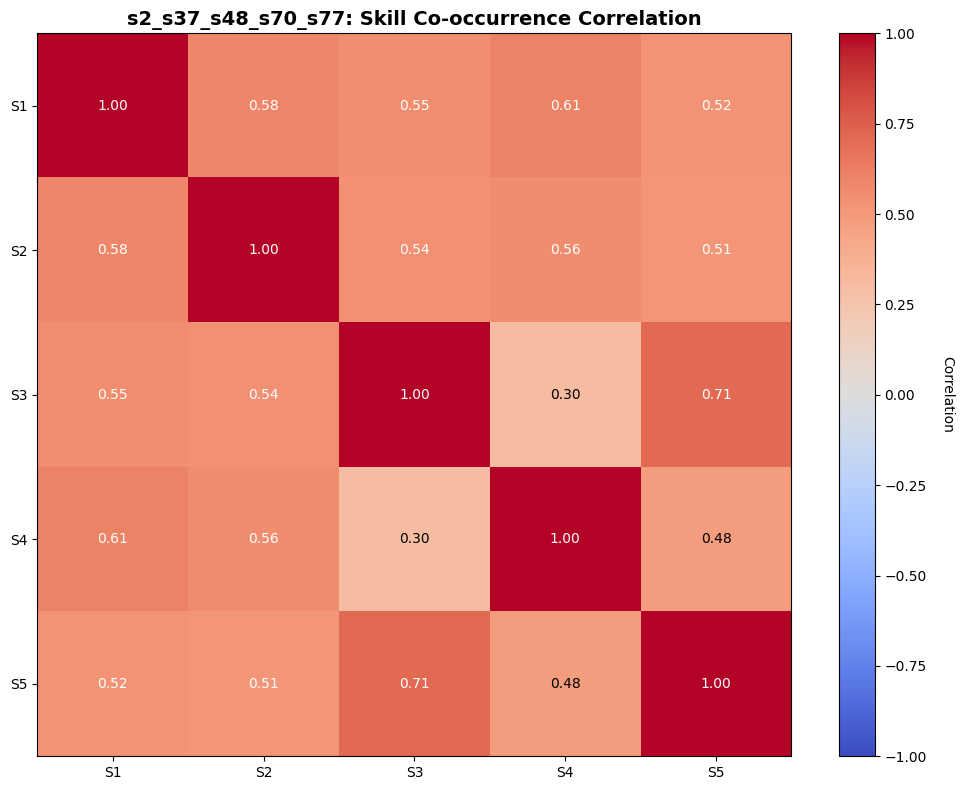

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 日本語フォント設定
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (14, 10)

for dataset_cfg in base_cfg["dataset"]:
    pre_current_dataset, pre_future_dataset = generate_data(
        data_dir=dataset_cfg["id"], 
        n_skills=dataset_cfg["n_skills"],
        raw_future=True
    )
    
    # 現在の習得状態と将来の習得状態
    current_skills = pre_future_dataset[:, 0, :]  # (n_students, n_skills)
    future_skills = pre_future_dataset[:, 1, :]   # (n_students, n_skills)
    
    n_skills = dataset_cfg["n_skills"]
    n_students = len(current_skills)
    
    print(f"\n=== Dataset: {dataset_cfg['name']} ===")
    print(f"Number of students: {n_students}")
    print(f"Number of skills: {n_skills}")
    
    # 各スキルの習得人数を集計
    current_counts = current_skills.sum(axis=0)  # (n_skills,)
    future_counts = future_skills.sum(axis=0)    # (n_skills,)
    new_learners = future_counts - current_counts  # 新規習得者数
    
    # 学生ごとの総習得スキル数
    current_total_per_student = current_skills.sum(axis=1)  # (n_students,)
    future_total_per_student = future_skills.sum(axis=1)    # (n_students,)
    new_skills_per_student = future_total_per_student - current_total_per_student
    
    # データフレーム作成
    skill_stats = pd.DataFrame({
        'Skill': [f'Skill {i+1}' for i in range(n_skills)],
        'Current': current_counts,
        'Future': future_counts,
        'New Learners': new_learners
    })
    
    print("\nSkill Statistics:")
    display(skill_stats)
    
    # === グラフ1: 総習得スキル数の分布 ===
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. 現在の総習得スキル数の分布（ヒストグラム）
    ax1 = axes[0, 0]
    ax1.hist(current_total_per_student, bins=range(0, n_skills+2), 
             alpha=0.7, color='steelblue', edgecolor='black', rwidth=0.8)
    ax1.axvline(current_total_per_student.mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {current_total_per_student.mean():.2f}')
    ax1.set_xlabel('Number of Skills Mastered', fontsize=12)
    ax1.set_ylabel('Number of Students', fontsize=12)
    ax1.set_title(f'{dataset_cfg["name"]}: Current Total Skills Distribution', 
                  fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_xticks(range(0, n_skills+1))
    
    # 2. 将来の総習得スキル数の分布（ヒストグラム）
    ax2 = axes[0, 1]
    ax2.hist(future_total_per_student, bins=range(0, n_skills+2), 
             alpha=0.7, color='coral', edgecolor='black', rwidth=0.8)
    ax2.axvline(future_total_per_student.mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {future_total_per_student.mean():.2f}')
    ax2.set_xlabel('Number of Skills Mastered', fontsize=12)
    ax2.set_ylabel('Number of Students', fontsize=12)
    ax2.set_title(f'{dataset_cfg["name"]}: Future Total Skills Distribution', 
                  fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    ax2.set_xticks(range(0, n_skills+1))
    
    # 3. 新規習得スキル数の分布（ヒストグラム）
    ax3 = axes[0, 2]
    ax3.hist(new_skills_per_student, bins=range(0, n_skills+2), 
             alpha=0.7, color='green', edgecolor='black', rwidth=0.8)
    ax3.axvline(new_skills_per_student.mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {new_skills_per_student.mean():.2f}')
    ax3.set_xlabel('Number of New Skills Learned', fontsize=12)
    ax3.set_ylabel('Number of Students', fontsize=12)
    ax3.set_title(f'{dataset_cfg["name"]}: New Skills Distribution', 
                  fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    ax3.set_xticks(range(0, n_skills+1))
    
    # 4. 現在 vs 将来の散布図
    ax4 = axes[1, 0]
    ax4.scatter(current_total_per_student, future_total_per_student, 
                alpha=0.6, s=50, color='purple')
    ax4.plot([0, n_skills], [0, n_skills], 'r--', linewidth=2, label='No change line')
    ax4.set_xlabel('Current Total Skills', fontsize=12)
    ax4.set_ylabel('Future Total Skills', fontsize=12)
    ax4.set_title(f'{dataset_cfg["name"]}: Current vs Future Skills', 
                  fontsize=14, fontweight='bold')
    ax4.legend()
    ax4.grid(alpha=0.3)
    ax4.set_xlim(-0.5, n_skills+0.5)
    ax4.set_ylim(-0.5, n_skills+0.5)
    
    # 5. 箱ひげ図（現在、将来、新規）
    ax5 = axes[1, 1]
    box_data = [current_total_per_student, future_total_per_student, new_skills_per_student]
    bp = ax5.boxplot(box_data, labels=['Current', 'Future', 'New'], 
                     patch_artist=True, showmeans=True)
    
    colors = ['steelblue', 'coral', 'green']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax5.set_ylabel('Number of Skills', fontsize=12)
    ax5.set_title(f'{dataset_cfg["name"]}: Skills Distribution Comparison', 
                  fontsize=14, fontweight='bold')
    ax5.grid(axis='y', alpha=0.3)
    
    # 6. 累積分布関数（CDF）
    ax6 = axes[1, 2]
    
    # 現在のCDF
    current_sorted = np.sort(current_total_per_student)
    current_cdf = np.arange(1, len(current_sorted)+1) / len(current_sorted)
    ax6.plot(current_sorted, current_cdf, marker='o', markersize=4, 
             linewidth=2, label='Current', color='steelblue')
    
    # 将来のCDF
    future_sorted = np.sort(future_total_per_student)
    future_cdf = np.arange(1, len(future_sorted)+1) / len(future_sorted)
    ax6.plot(future_sorted, future_cdf, marker='s', markersize=4, 
             linewidth=2, label='Future', color='coral')
    
    ax6.set_xlabel('Number of Skills Mastered', fontsize=12)
    ax6.set_ylabel('Cumulative Probability', fontsize=12)
    ax6.set_title(f'{dataset_cfg["name"]}: Cumulative Distribution', 
                  fontsize=14, fontweight='bold')
    ax6.legend()
    ax6.grid(alpha=0.3)
    ax6.set_xlim(-0.5, n_skills+0.5)
    
    plt.tight_layout()
    plt.show()
    
    # === 統計サマリー（総習得スキル数） ===
    print("\n=== Total Skills Statistics ===")
    print(f"Current Total Skills:")
    print(f"  Mean: {current_total_per_student.mean():.2f}")
    print(f"  Std: {current_total_per_student.std():.2f}")
    print(f"  Min: {current_total_per_student.min():.0f}")
    print(f"  Max: {current_total_per_student.max():.0f}")
    print(f"  Median: {np.median(current_total_per_student):.0f}")
    
    print(f"\nFuture Total Skills:")
    print(f"  Mean: {future_total_per_student.mean():.2f}")
    print(f"  Std: {future_total_per_student.std():.2f}")
    print(f"  Min: {future_total_per_student.min():.0f}")
    print(f"  Max: {future_total_per_student.max():.0f}")
    print(f"  Median: {np.median(future_total_per_student):.0f}")
    
    print(f"\nNew Skills Learned:")
    print(f"  Mean: {new_skills_per_student.mean():.2f}")
    print(f"  Std: {new_skills_per_student.std():.2f}")
    print(f"  Min: {new_skills_per_student.min():.0f}")
    print(f"  Max: {new_skills_per_student.max():.0f}")
    print(f"  Median: {np.median(new_skills_per_student):.0f}")
    
    # 分布の詳細
    print(f"\n=== Distribution Details ===")
    for i in range(0, n_skills+1):
        current_count = (current_total_per_student == i).sum()
        future_count = (future_total_per_student == i).sum()
        new_count = (new_skills_per_student == i).sum()
        print(f"{i} skills: Current={current_count}, Future={future_count}, New={new_count}")
    
    # === 以前のグラフ（スキルごと） ===
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. 習得人数の比較（棒グラフ）
    ax1 = axes[0, 0]
    x = np.arange(n_skills)
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, current_counts, width, label='Current', alpha=0.8, color='steelblue')
    bars2 = ax1.bar(x + width/2, future_counts, width, label='Future', alpha=0.8, color='coral')
    
    ax1.set_xlabel('Skill', fontsize=12)
    ax1.set_ylabel('Number of Students', fontsize=12)
    ax1.set_title(f'{dataset_cfg["name"]}: Current vs Future Skill Mastery', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # 棒の上に数値を表示
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=9)
    
    # 2. 新規習得者数（棒グラフ）
    ax2 = axes[0, 1]
    bars3 = ax2.bar(x, new_learners, color='green', alpha=0.7)
    
    ax2.set_xlabel('Skill', fontsize=12)
    ax2.set_ylabel('Number of New Learners', fontsize=12)
    ax2.set_title(f'{dataset_cfg["name"]}: New Learners per Skill', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
    ax2.grid(axis='y', alpha=0.3)
    
    for bar in bars3:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9)
    
    # 3. 習得率の比較（折れ線グラフ）
    ax3 = axes[1, 0]
    current_rate = (current_counts / n_students) * 100
    future_rate = (future_counts / n_students) * 100
    
    ax3.plot(x, current_rate, marker='o', linewidth=2, markersize=8, label='Current', color='steelblue')
    ax3.plot(x, future_rate, marker='s', linewidth=2, markersize=8, label='Future', color='coral')
    
    ax3.set_xlabel('Skill', fontsize=12)
    ax3.set_ylabel('Mastery Rate (%)', fontsize=12)
    ax3.set_title(f'{dataset_cfg["name"]}: Skill Mastery Rate', fontsize=14, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
    ax3.legend()
    ax3.grid(alpha=0.3)
    ax3.set_ylim(0, 100)
    
    # 4. ヒートマップ（習得パターン）
    ax4 = axes[1, 1]
    
    # 習得状態の変化を可視化（サンプル50人まで）
    sample_size = min(50, n_students)
    indices = np.random.choice(n_students, sample_size, replace=False)
    
    # 現在と将来を縦に並べる
    combined = np.vstack([
        current_skills[indices],
        np.full((2, n_skills), np.nan),  # セパレータ
        future_skills[indices]
    ])
    
    im = ax4.imshow(combined, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax4.set_xlabel('Skill', fontsize=12)
    ax4.set_ylabel('Student', fontsize=12)
    ax4.set_title(f'{dataset_cfg["name"]}: Skill Mastery Pattern (Sample)', fontsize=14, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
    
    # Y軸のラベル
    yticks_pos = [sample_size//2, sample_size + 1, sample_size + 2 + sample_size//2]
    yticks_labels = ['Current', '---', 'Future']
    ax4.set_yticks(yticks_pos)
    ax4.set_yticklabels(yticks_labels)
    
    # カラーバー
    cbar = plt.colorbar(im, ax=ax4)
    cbar.set_label('Mastery (0=Not Mastered, 1=Mastered)', rotation=270, labelpad=20)
    
    plt.tight_layout()
    plt.show()
    
    # スキル間の相関（現在の習得状態）
    if n_skills > 1:
        print("\n=== Skill Co-occurrence (Current) ===")
        skill_corr = np.corrcoef(current_skills.T)
        
        fig, ax = plt.subplots(figsize=(10, 8))
        im = ax.imshow(skill_corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
        
        ax.set_xticks(x)
        ax.set_yticks(x)
        ax.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
        ax.set_yticklabels([f'S{i+1}' for i in range(n_skills)])
        ax.set_title(f'{dataset_cfg["name"]}: Skill Co-occurrence Correlation', fontsize=14, fontweight='bold')
        
        # 数値を表示
        for i in range(n_skills):
            for j in range(n_skills):
                text = ax.text(j, i, f'{skill_corr[i, j]:.2f}',
                             ha="center", va="center", color="black" if abs(skill_corr[i, j]) < 0.5 else "white",
                             fontsize=10)
        
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Correlation', rotation=270, labelpad=20)
        plt.tight_layout()
        plt.show()

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# データ読み込み
data_path = Path("../../data/raw/assistments_2009_2010/skill_builder_data.csv")
df = pd.read_csv(data_path, encoding='latin1')

# 指定したスキルID
target_skills = [2, 48, 77, 37, 70]

print(f"=== Analysis: Skills co-occurring with {target_skills} ===")
print(f"Condition: Users must have ALL target skills in BOTH first-half and second-half")
print(f"Method: Filter to target skills FIRST, then split timeline\n")

# まずターゲットスキルのみにフィルタリング（スクリプトの方法）
df_filtered = df[df['skill_id'].isin(target_skills)].copy()
df_filtered = df_filtered.sort_values(['user_id', 'order_id']).reset_index(drop=True)

print(f"Total users in dataset: {df['user_id'].nunique()}")
print(f"Users with any target skill: {df_filtered['user_id'].nunique()}")

# 各ユーザーのフィルタ済みデータを前半・後半に分割
target_skill_set = set(target_skills)
users_with_temporal_coverage = []

for user_id, user_data in df_filtered.groupby('user_id'):
    n = len(user_data)
    mid = n // 2
    
    # フィルタ済みデータでの前半・後半のスキルセット
    first_half_skills = set(user_data.iloc[:mid]['skill_id'].dropna())
    second_half_skills = set(user_data.iloc[mid:]['skill_id'].dropna())
    
    # 前半・後半両方でターゲットスキルを全て持つか
    has_first = target_skill_set.issubset(first_half_skills)
    has_second = target_skill_set.issubset(second_half_skills)
    
    if has_first and has_second:
        users_with_temporal_coverage.append(user_id)

print(f"Users with ALL target skills in BOTH periods: {len(users_with_temporal_coverage)}")
print(f"Percentage: {len(users_with_temporal_coverage) / df['user_id'].nunique() * 100:.2f}%\n")

if len(users_with_temporal_coverage) == 0:
    print("No users have all the target skills in both first-half and second-half.")
else:
    # これらのユーザーが持つ全スキルを集計（元の全データから）
    other_skills_counts = {}
    
    for user_id in users_with_temporal_coverage:
        # 元のデータフレームから全スキルを取得
        user_data = df[df['user_id'] == user_id]
        user_skill_set = set(user_data['skill_id'].dropna())
        
        # ターゲットスキル以外のスキル
        other_skills = user_skill_set - target_skill_set
        
        for skill in other_skills:
            other_skills_counts[skill] = other_skills_counts.get(skill, 0) + 1
    
    # 割合を計算してソート
    total_target_users = len(users_with_temporal_coverage)
    
    co_occurrence_data = []
    for skill_id, count in other_skills_counts.items():
        percentage = (count / total_target_users) * 100
        
        # スキル名を取得
        skill_name_series = df[df['skill_id'] == skill_id]['skill_name'].dropna()
        skill_name = skill_name_series.iloc[0] if len(skill_name_series) > 0 else "Unknown"
        
        co_occurrence_data.append({
            'skill_id': skill_id,
            'skill_name': skill_name,
            'count': count,
            'percentage': percentage
        })
    
    # DataFrameに変換してソート
    co_occurrence_df = pd.DataFrame(co_occurrence_data)
    co_occurrence_df = co_occurrence_df.sort_values('percentage', ascending=False)
    
    print(f"\n=== Skills co-occurring with target skills (sorted by percentage) ===")
    print(f"Base: {total_target_users} users who have ALL of {target_skills} in BOTH periods\n")
    
    # 全結果を表示
    with pd.option_context('display.max_rows', None, 'display.max_columns', None):
        display(co_occurrence_df)
    
    # 上位10件の詳細表示
    print(f"\n=== Top 10 Most Co-occurring Skills ===")
    for idx, row in co_occurrence_df.head(10).iterrows():
        print(f"{int(row['skill_id']):3d}. {row['skill_name']}")
        print(f"     Count: {int(row['count'])} / {total_target_users} ({row['percentage']:.1f}%)")
    
    # 高い割合のスキル（80%以上）
    high_cooccurrence = co_occurrence_df[co_occurrence_df['percentage'] >= 80]
    if len(high_cooccurrence) > 0:
        print(f"\n=== Skills with ≥80% co-occurrence ===")
        print(f"Found {len(high_cooccurrence)} skills:")
        for idx, row in high_cooccurrence.iterrows():
            print(f"  {int(row['skill_id']):3d}. {row['skill_name']} ({row['percentage']:.1f}%)")
    
    # さらに、前半・後半両方で共起するスキルも調べる
    print(f"\n=== Skills co-occurring in BOTH periods ===")
    
    temporal_co_occurrence = {}
    
    for user_id in users_with_temporal_coverage:
        # フィルタ済みデータで前半/後半を計算
        user_filtered = df_filtered[df_filtered['user_id'] == user_id]
        n = len(user_filtered)
        mid = n // 2
        
        # でも共起チェックは元の全データで
        user_all_data = df[df['user_id'] == user_id].sort_values('order_id')
        n_all = len(user_all_data)
        mid_all = n_all // 2
        
        first_half_skills = set(user_all_data.iloc[:mid_all]['skill_id'].dropna())
        second_half_skills = set(user_all_data.iloc[mid_all:]['skill_id'].dropna())
        
        # ターゲットスキル以外で、前半・後半両方に現れるスキル
        other_first = first_half_skills - target_skill_set
        other_second = second_half_skills - target_skill_set
        both_periods = other_first & other_second
        
        for skill in both_periods:
            temporal_co_occurrence[skill] = temporal_co_occurrence.get(skill, 0) + 1
    
    temporal_co_data = []
    for skill_id, count in temporal_co_occurrence.items():
        percentage = (count / total_target_users) * 100
        
        skill_name_series = df[df['skill_id'] == skill_id]['skill_name'].dropna()
        skill_name = skill_name_series.iloc[0] if len(skill_name_series) > 0 else "Unknown"
        
        temporal_co_data.append({
            'skill_id': skill_id,
            'skill_name': skill_name,
            'count': count,
            'percentage': percentage
        })
    
    temporal_co_df = pd.DataFrame(temporal_co_data)
    temporal_co_df = temporal_co_df.sort_values('percentage', ascending=False)
    
    print(f"Skills that appear in BOTH first-half and second-half:")
    with pd.option_context('display.max_rows', 20):
        display(temporal_co_df)
    
    # 可視化
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # 左: 全体の共起率
    ax1 = axes[0]
    top_n = min(20, len(co_occurrence_df))
    top_skills = co_occurrence_df.head(top_n)
    
    bars1 = ax1.barh(range(top_n), top_skills['percentage'].values, color='steelblue', alpha=0.8)
    ax1.set_yticks(range(top_n))
    ax1.set_yticklabels([f"S{int(row['skill_id'])}: {row['skill_name'][:35]}" 
                          for _, row in top_skills.iterrows()])
    ax1.set_xlabel('Co-occurrence Rate (%)', fontsize=12)
    ax1.set_title(f'Top {top_n} Skills Co-occurring with {target_skills}\n(Overall, Base: {total_target_users} users)', 
                  fontsize=13, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    for i, (idx, row) in enumerate(top_skills.iterrows()):
        ax1.text(row['percentage'] + 1, i, f"{row['percentage']:.1f}%", 
                va='center', fontsize=8)
    
    # 右: 前半・後半両方での共起率
    ax2 = axes[1]
    if len(temporal_co_df) > 0:
        top_n2 = min(20, len(temporal_co_df))
        top_temporal = temporal_co_df.head(top_n2)
        
        bars2 = ax2.barh(range(top_n2), top_temporal['percentage'].values, color='coral', alpha=0.8)
        ax2.set_yticks(range(top_n2))
        ax2.set_yticklabels([f"S{int(row['skill_id'])}: {row['skill_name'][:35]}" 
                              for _, row in top_temporal.iterrows()])
        ax2.set_xlabel('Co-occurrence Rate (%)', fontsize=12)
        ax2.set_title(f'Skills in BOTH Periods with {target_skills}\n(Temporal Coverage, Base: {total_target_users} users)', 
                      fontsize=13, fontweight='bold')
        ax2.grid(axis='x', alpha=0.3)
        
        for i, (idx, row) in enumerate(top_temporal.iterrows()):
            ax2.text(row['percentage'] + 1, i, f"{row['percentage']:.1f}%", 
                    va='center', fontsize=8)
    else:
        ax2.text(0.5, 0.5, 'No skills appear in both periods', 
                ha='center', va='center', fontsize=14)
        ax2.set_xlim(0, 1)
        ax2.set_ylim(0, 1)
        ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../../data/raw/assistments_2009_2010/skill_builder_data.csv'